In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Încărcare date (aceeași folder ca notebook-ul)
df = pd.read_csv("World_cup.csv")
df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26


## 1. Date și tipuri: calitative vs cantitative

**Categorii  (Calitative)** descriu calități, nu mărimi numerice directe:
- **Nominal**: categorii fără ordine naturală (ex.: țara câștigătoare, nume de țări). Nu are sens să „ordonezi” Brazilia înaintea Italiei doar din nume.
- **Ordinal**: categorii cu ordine logică, dar diferențele între trepte nu sunt neapărat egale (ex.: clasament final 1–4: câștigător, finalist, loc 3, loc 4).

**Numerice  (Cantitative)** pot fi măsurate sau numărate:
- **Discrete**: valori numărabile, de obicei întregi (ex.: număr de echipe calificate, meciuri jucate, goluri marcate în turneu — deși golurile sunt „numărabile”, le tratăm adesea ca discrete în context).
- **Continuu** (în teorie): orice valoare dintr-un interval; în setul nostru, anul poate fi tratat ca temporal; pentru simplificare, `Year` apare ca întregi, dar timpul este continuu în realitate. Coloanele `GoalsScored`, `QualifiedTeams`, `MatchesPlayed` sunt cantitative discrete în practică.


## 2. Tendențe centrale: medie, mediană, modă

- **Medie (mean)**: suma valorilor / numărul de valori; sensibilă la valori extreme.
- **Mediană (median)**: valoarea din mijloc după sortare (sau media celor două din mijloc); mai robustă la outlier-e.
- **Modă (mode)**: valoarea (sau categoria) cea mai frecventă; pentru date calitative, „cea mai comună categorie”.


In [3]:
g = df["GoalsScored"]
mean_g = g.mean()
median_g = g.median()
mode_g = g.mode()

print(f"Goluri marcate (per turneu): medie = {mean_g:.2f}")
print(f"Mediană = {median_g}")
print("Modă (valori cele mai frecvente):", mode_g.tolist())

Goluri marcate (per turneu): medie = 123.64
Mediană = 129.0
Modă (valori cele mai frecvente): [70, 89, 171]


## 3. Măsurarea spread-ului (împrăștierii datelor) 

- **Range (interval)** Intervalul este o măsură a variației, care descrie cât de dispersate sunt datele.
- **IQR (Interquartile Range)**: Intervalul intercuartil este o măsură a variației, care descrie cât de dispersate sunt datele
- **Modă (mode)**: Abaterea standard este cea mai frecvent utilizată măsură a variației, care descrie cât de dispersate sunt datele.

## 4. Tipuri de grafice: categorice vs numerice (calitative vs cantitative)

**Calitative (categorii)** descriu calități, nu mărimi numerice directe:
- **Bar Chart** Arată frecvența valorilor din date
- **Pie Chart** Arată frecvența sau frecvența relativă a valorilor din date.

**Cantitative (numerice)** pot fi măsurate sau numărate:
- **Histogram**: Arată frecvența valorilor din date, de obicei în intervale de valori.
- **BoxPlot**: Arată mediana datelor. Aceasta este valoarea din mijloc a datelor și un tip de valoare medie. De asemenea, arată intervalul și quartilele datelor.


## 1. Bar Chart

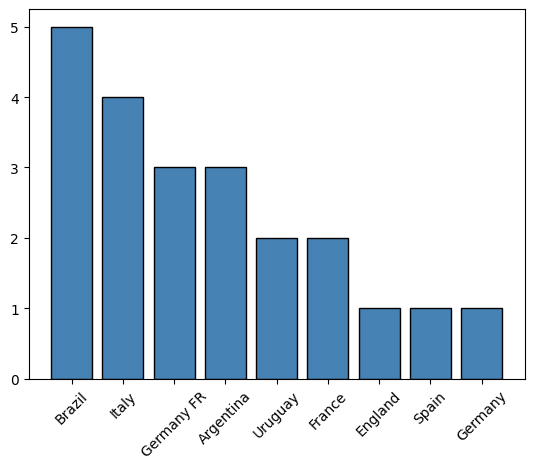

In [4]:
winner_counts = df["Winner"].value_counts()
plt.bar(winner_counts.index, winner_counts.values, color="steelblue", edgecolor="black")
plt.xticks(rotation = 45);

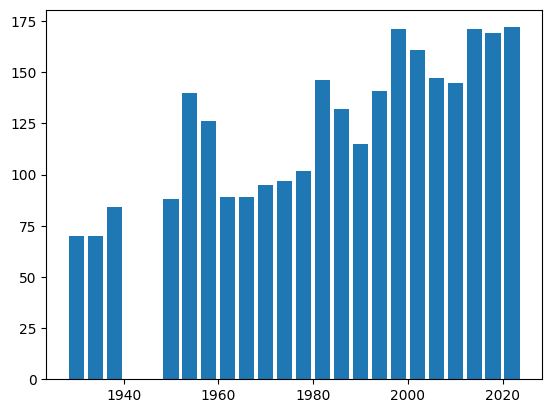

In [30]:
plt.bar(df['Year'], df['GoalsScored'],width=3.2);

# 2. Pie Chart

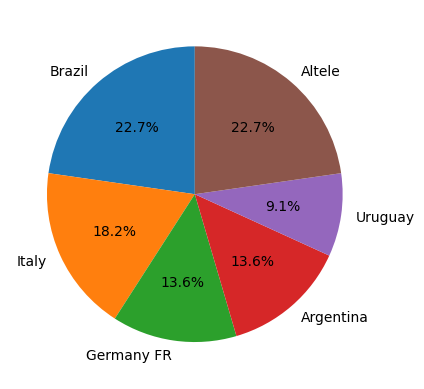

In [6]:
top5 = winner_counts.head(5)
other = winner_counts.iloc[5:].sum()
pie_labels = list(top5.index) + (["Altele"] if other > 0 else [])
pie_sizes = list(top5.values) + ([other] if other > 0 else [])
plt.pie(pie_sizes, labels=pie_labels, autopct="%1.1f%%", startangle=90);

# 3. Histograma 

Text(0, 0.5, 'Frecvență')

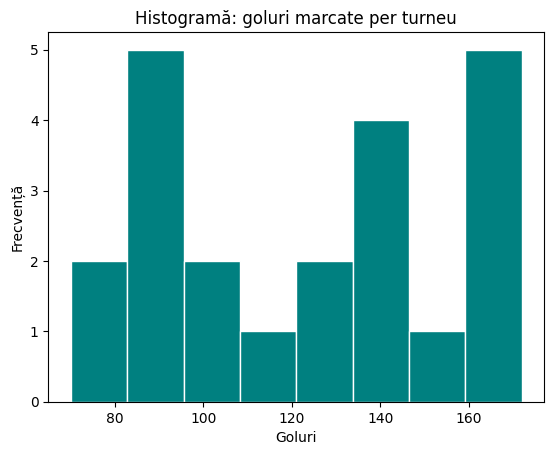

In [7]:
plt.hist(df["GoalsScored"], bins=8, color="teal", edgecolor="white")
plt.title("Histogramă: goluri marcate per turneu")
plt.xlabel("Goluri")
plt.ylabel("Frecvență")

# 4. Boxplot

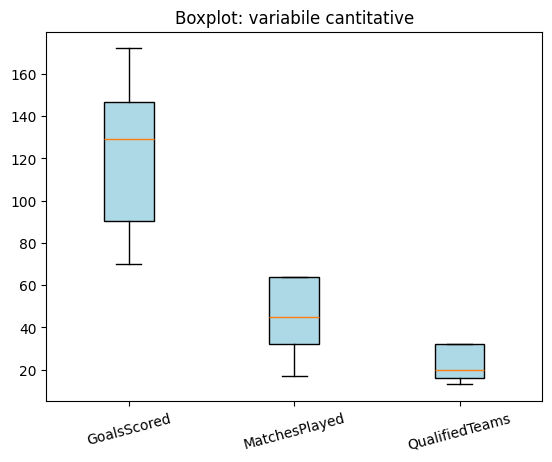

In [8]:
cols_box = ["GoalsScored", "MatchesPlayed", "QualifiedTeams"]
bp = plt.boxplot([df[c] for c in cols_box], tick_labels=cols_box, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue") # coloreaza
plt.title("Boxplot: variabile cantitative")
plt.tick_params(axis="x", rotation=15)

# Seaborn

De ce să combinăm matplotlib și seaborn? 
Seaborn facilitează crearea grafică, dar este construit pe baza Matplotlib, astfel încât le putem folosi pe amândouă împreună pentru rezultate mai bune: 

- Personalizare: Matplotlib ne permite să controlăm complet graficul (axe, etichete, grilă, culori etc.). 
- Aspect mai bun: Seaborn are teme și stiluri încorporate care fac graficele să arate mai frumos. 
- Grafice statistice: Seaborn include grafice speciale, cum ar fi graficele tip vioară și graficele KDE. 
- Mai multă flexibilitate: Matplotlib permite personalizare suplimentară și combinarea mai multor grafice.

# 1. CATEGORICAL PLOTS
## 1.1. Barplot

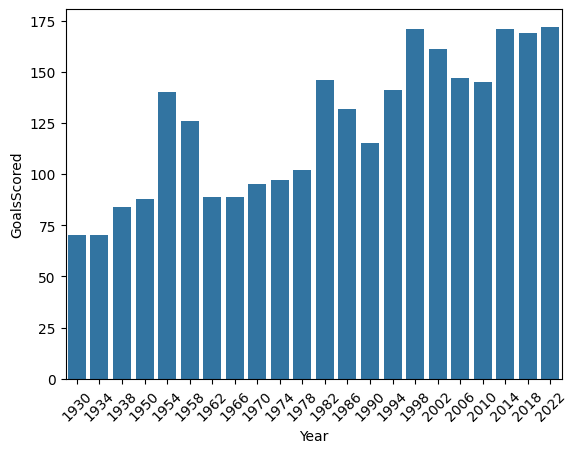

In [9]:
# plt.bar(df['Year'], df['GoalsScored']);

sns.barplot(x = 'Year', y = 'GoalsScored', data = df);
plt.xticks(rotation = 45);

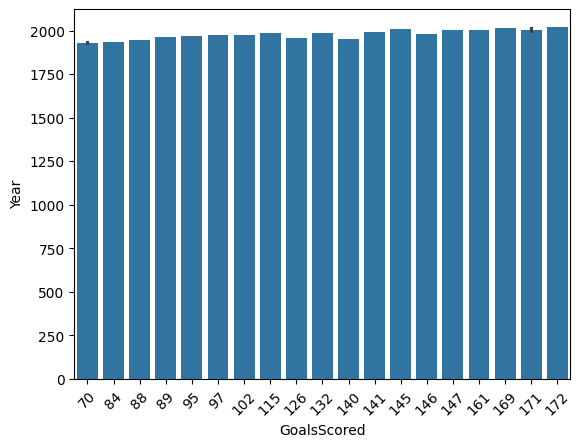

In [10]:
sns.barplot(x = 'GoalsScored', y = 'Year', data = df);
plt.xticks(rotation = 45);

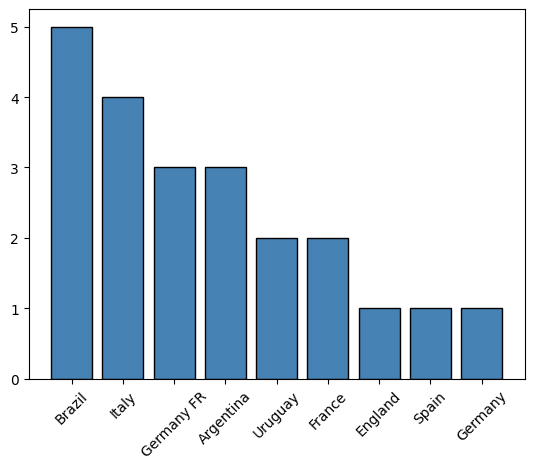

In [11]:
winner_counts = df["Winner"].value_counts()
plt.bar(winner_counts.index, winner_counts.values, color="steelblue", edgecolor="black")
plt.xticks(rotation = 45);

# 1.2 Countplot

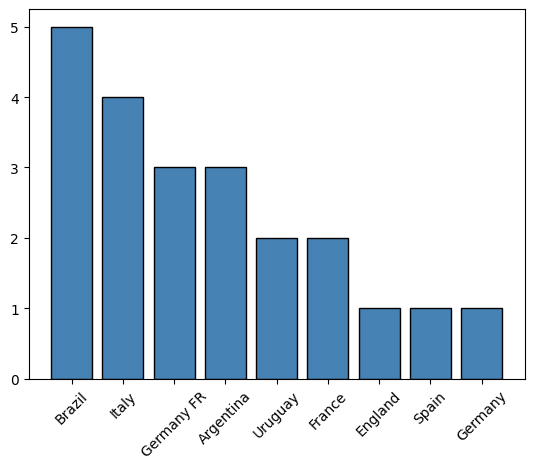

In [12]:
winner_counts = df["Winner"].value_counts()
plt.bar(winner_counts.index, winner_counts.values, color="steelblue", edgecolor="black")
plt.xticks(rotation = 45);

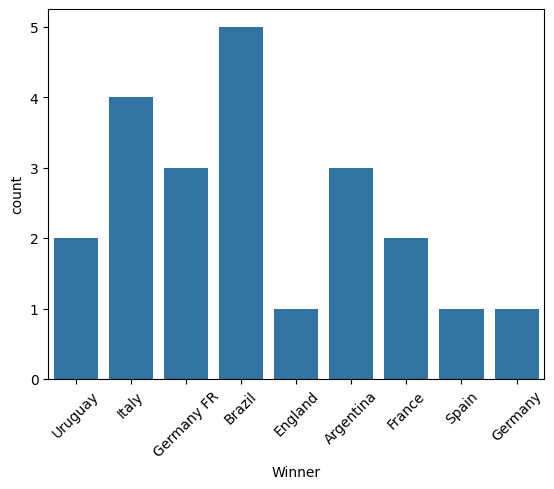

In [32]:
sns.countplot(x ='Winner', data = df)#, edgecolor="black")
plt.xticks(rotation = 45);

<Axes: xlabel='count', ylabel='Winner'>

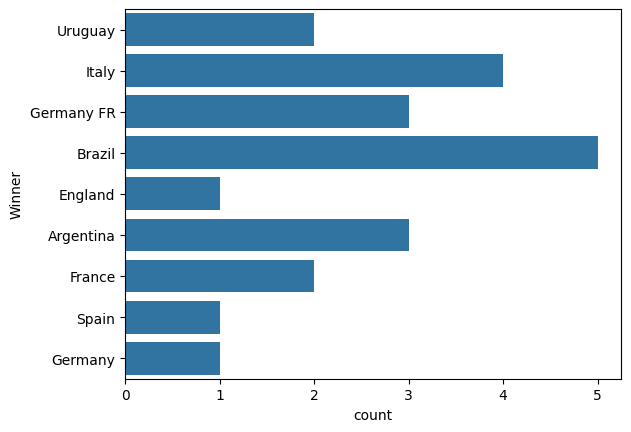

In [14]:
sns.countplot(y ='Winner', data = df)
# plt.xticks(rotation = 45);

<Axes: xlabel='count', ylabel='Winner'>

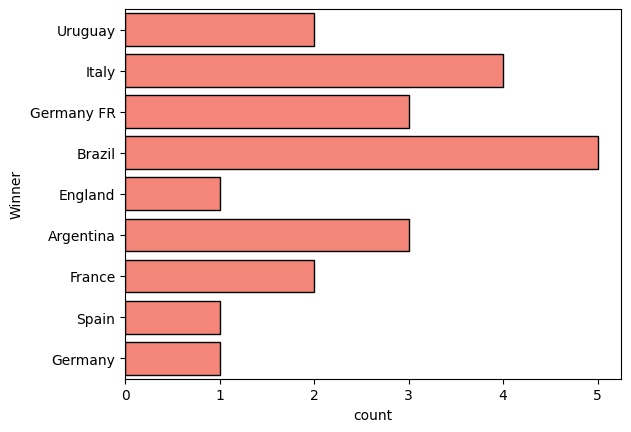

In [15]:
sns.countplot(y ='Winner', data = df, color = "salmon",  saturation = 0.9, edgecolor = "black")

# 2.1 Boxplot

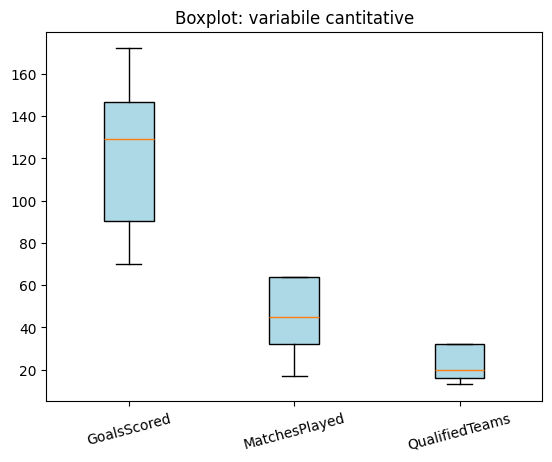

In [16]:
cols_box = ["GoalsScored", "MatchesPlayed", "QualifiedTeams"]
bp = plt.boxplot([df[c] for c in cols_box], tick_labels=cols_box, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue") # coloreaza
plt.title("Boxplot: variabile cantitative")
plt.tick_params(axis="x", rotation=15)

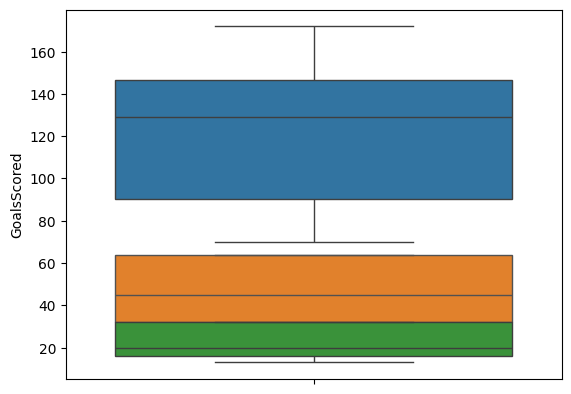

In [34]:
sns.boxplot(y = 'GoalsScored', data = df)
sns.boxplot(y = 'MatchesPlayed', data = df)
sns.boxplot(y = 'QualifiedTeams', data = df)
plt.xticks(rotation = 45);
# sns.boxplot(x = 'Winner', y = 'GoalsScored', data = df, color = "salmon", saturation = 0.9, edgecolor = "black")
# # 4.1 Scatterplot
# sns.scatterplot(x = 'Year', y = 'GoalsScored', data = df)
# sns.scatterplot(x = 'Year', y = 'GoalsScored', data = df, color = "salmon", saturation = 0.9, edgecolor = "black")


# 2.2.  Histogram

<Axes: xlabel='GoalsScored', ylabel='Count'>

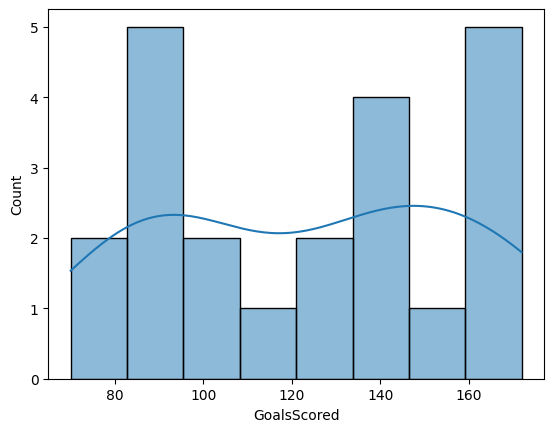

In [18]:
sns.histplot(data = df, x = "GoalsScored", kde = True, bins = 8)

# Violinplot


- Ce face: arată forma distribuției (densitatea) pentru GoalsScored pe fiecare Winner + (aici) și quartilele.
- Când e util: când vrei mai mult decât boxplot (nu doar mediană/IQR), ci și unde se „adună” valorile.

In [19]:
top_winners = df["Winner"].value_counts().head(8).index
df_top = df[df["Winner"].isin(top_winners)]

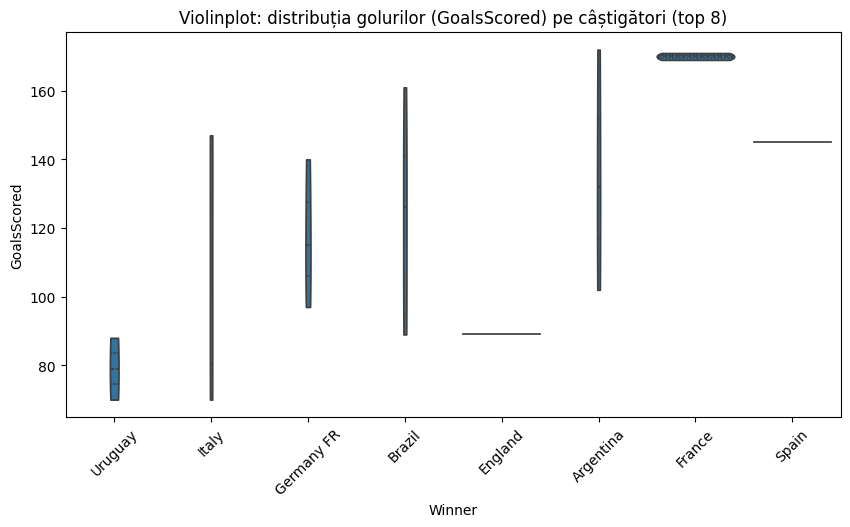

In [20]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df_top, x="Winner", y="GoalsScored", inner="quartile", cut=0)
plt.xticks(rotation=45)
plt.title("Violinplot: distribuția golurilor (GoalsScored) pe câștigători (top 8)")
plt.show()

# Stripplot

- Ce face: plotează fiecare observație ca punct; jitter evită suprapunerea completă.
- Când e util: pentru a vedea dispersia reală și eventuale grupări/outlieri.

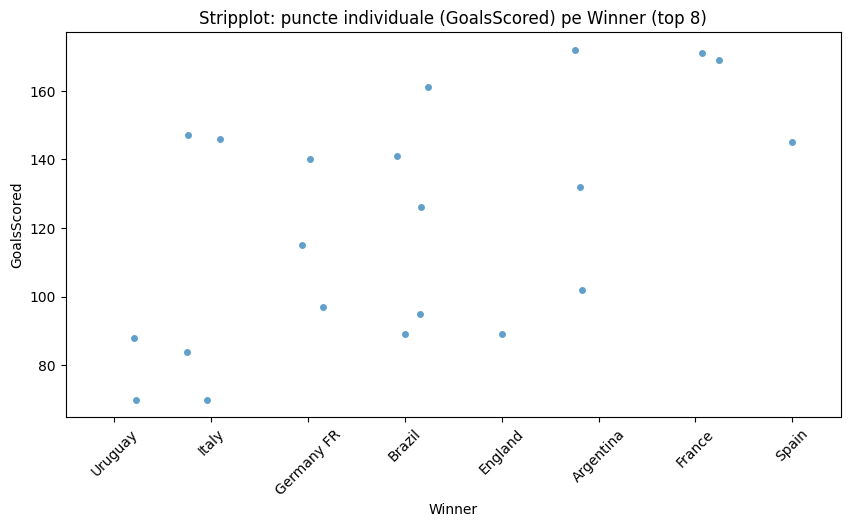

In [21]:
plt.figure(figsize=(10,5))
sns.stripplot(data=df_top, x="Winner", y="GoalsScored", jitter=0.25, alpha=0.7)
plt.xticks(rotation=45)
plt.title("Stripplot: puncte individuale (GoalsScored) pe Winner (top 8)")
plt.show()

# Swarmplot


- Ce face: ca stripplot, dar încearcă să nu suprapună punctele (le „împrăștie” inteligent).
- Când e util: când vrei puncte individuale, dar cu overlap minim (atenție: poate fi lent pe multe date).

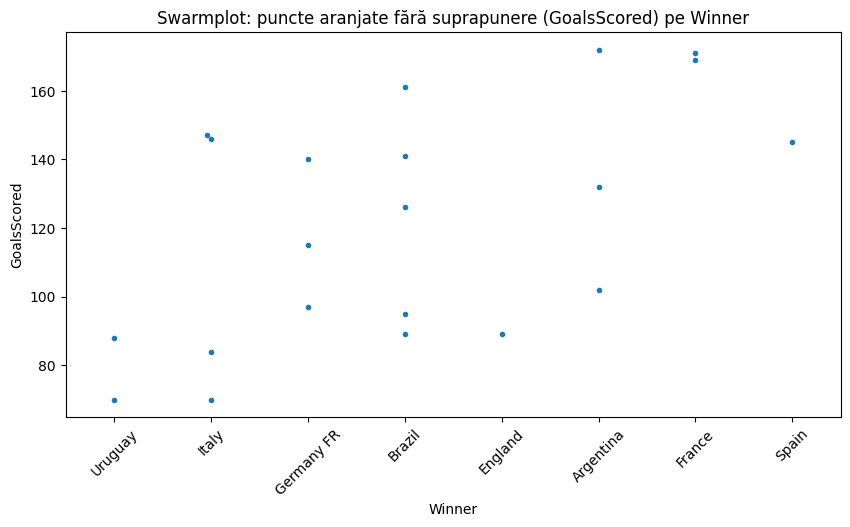

In [22]:
plt.figure(figsize=(10,5))
sns.swarmplot(data=df_top, x="Winner", y="GoalsScored", size=4)
plt.xticks(rotation=45)
plt.title("Swarmplot: puncte aranjate fără suprapunere (GoalsScored) pe Winner")
plt.show()

# Factorplot

- Ce face: era „interfața” de nivel înalt pentru grafice categorice; acum e catplot.
- Când e util: când vrei să schimbi rapid tipul (kind="box", "violin", "strip", "point", etc.) și/sau să folosești faceting.

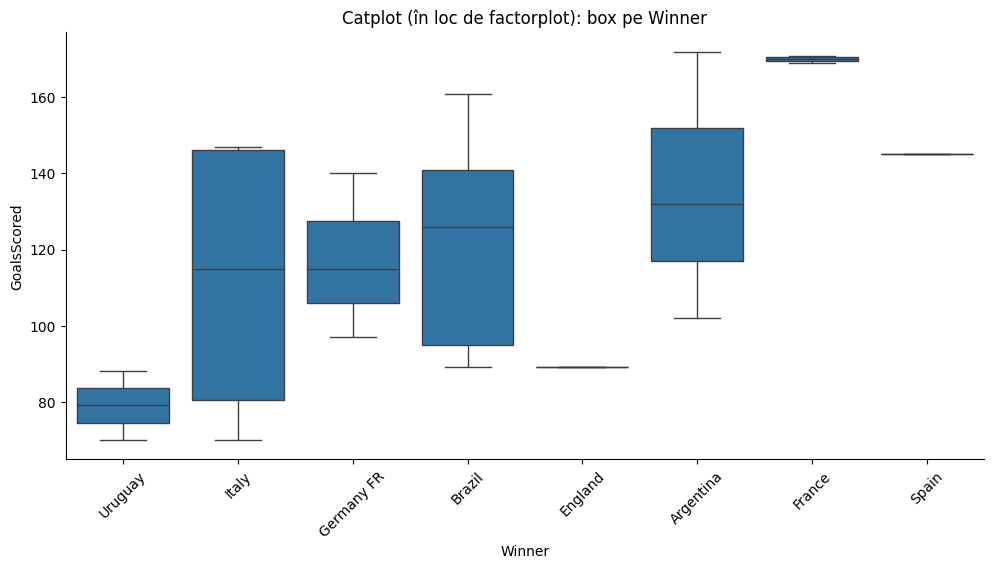

In [23]:
sns.catplot(data=df_top, x="Winner", y="GoalsScored", kind="box", height=5, aspect=2)
plt.xticks(rotation=45)
plt.title("Catplot (în loc de factorplot): box pe Winner")
plt.show()

# Jointplot


- Ce face: combină un scatter între 2 variabile + distribuțiile marginale (hist/kde) pe fiecare axă.
- Când e util: când vrei simultan relația dintre variabile și cum sunt ele distribuite.

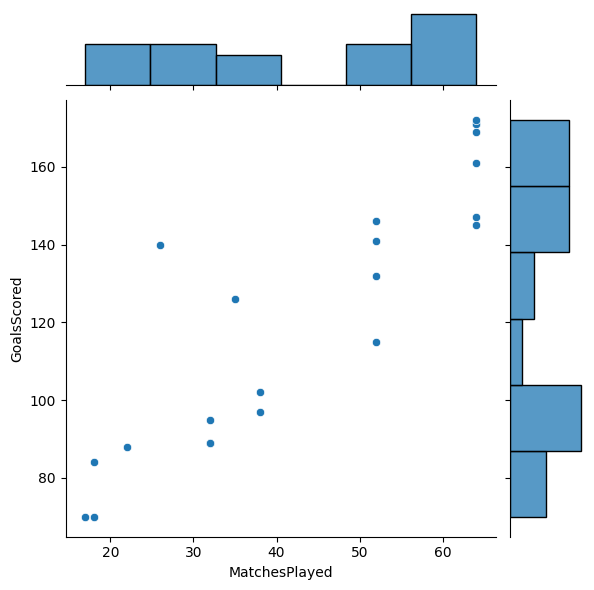

In [24]:
sns.jointplot(data=df, x="MatchesPlayed", y="GoalsScored", kind="scatter", height=6)
plt.show()

# Pairplot


- Ce face: matrice de scatter-uri pentru toate perechile de variabile + distribuții pe diagonală.
- Când e util: explorare rapidă: corelații, non-liniarități, outlieri între multe coloane numerice.

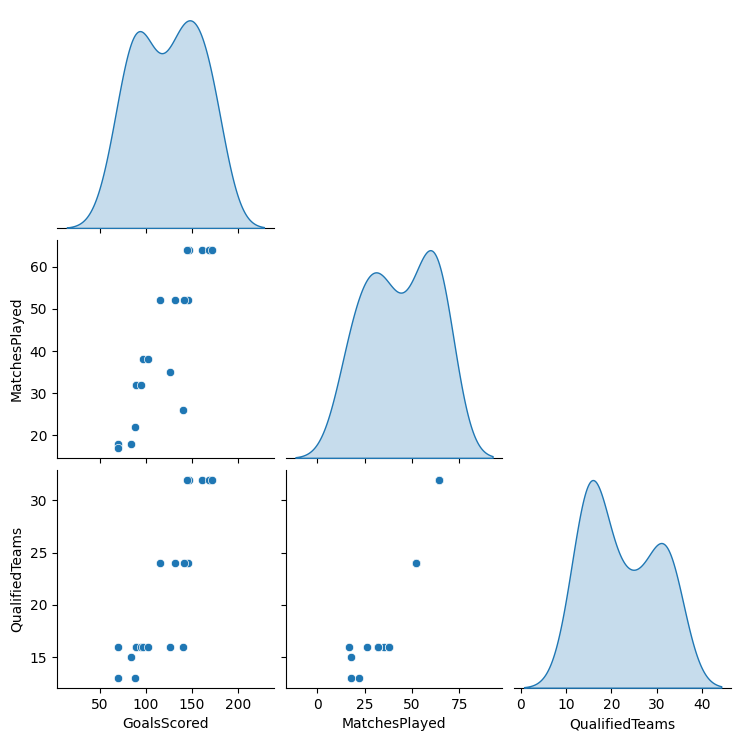

In [25]:
cols = ["GoalsScored", "MatchesPlayed", "QualifiedTeams"]
sns.pairplot(df[cols], corner=True, diag_kind="kde")
plt.show()

# KDE Plot

- Ce face: estimează o curbă netezită a distribuției (densitate).
- Când e util: alternativă „smooth” la histogramă, bună pentru a vedea moduri (vârfuri) și asimetrie.

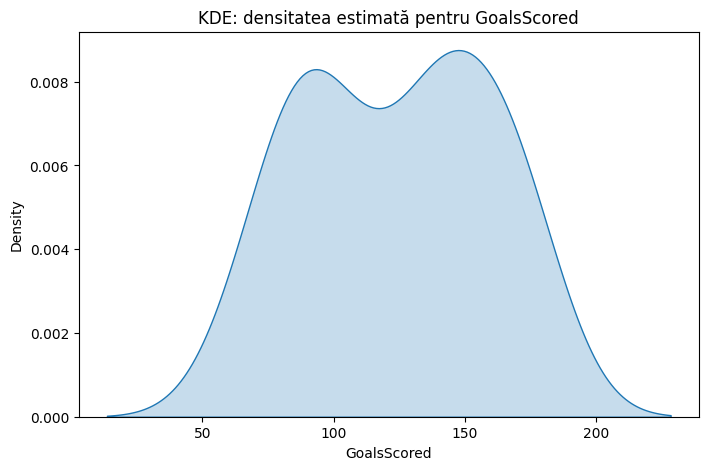

In [26]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="GoalsScored", fill=True)
plt.title("KDE: densitatea estimată pentru GoalsScored")
plt.show()

# Heatmap

- Ce face: reprezintă o matrice (aici corelații) prin culori + valori.
- Când e util: ca să vezi rapid ce variabile se mișcă împreună (pozitiv/negativ).


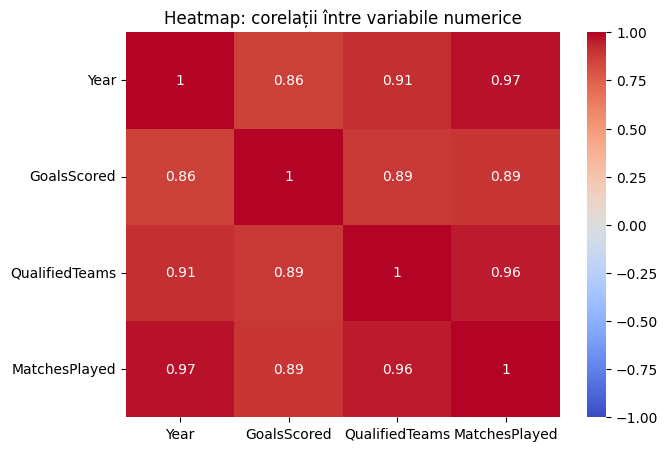

In [27]:
num = df[["Year", "GoalsScored", "QualifiedTeams", "MatchesPlayed"]]
corr = num.corr(numeric_only=True)

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap: corelații între variabile numerice")
plt.show()

# Bubble Plot

- Ce face: arată relația între 2 variabile și „încarcă” o a 3-a în mărimea bulei.
- Când e util: când vrei un scatter „3D” pe 2D (cu grijă la scaling-ul lui s).

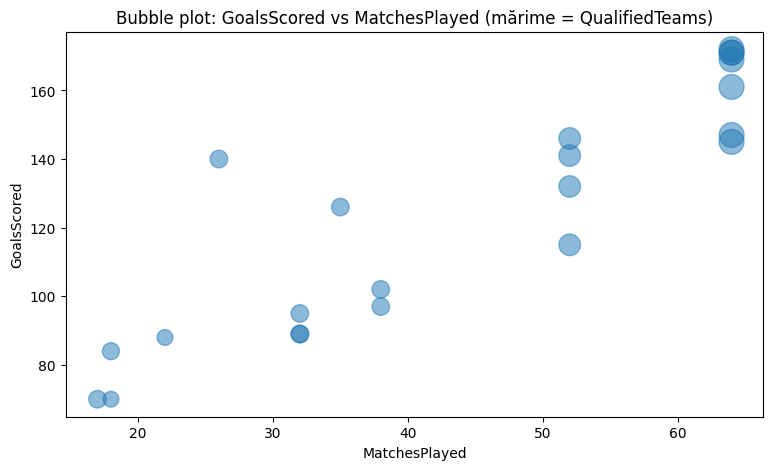

In [28]:
plt.figure(figsize=(9,5))
plt.scatter(
    df["MatchesPlayed"], df["GoalsScored"],
    s=df["QualifiedTeams"]*10, alpha=0.5
)
plt.xlabel("MatchesPlayed")
plt.ylabel("GoalsScored")
plt.title("Bubble plot: GoalsScored vs MatchesPlayed (mărime = QualifiedTeams)")
plt.show()

# Residplot (residplot)

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

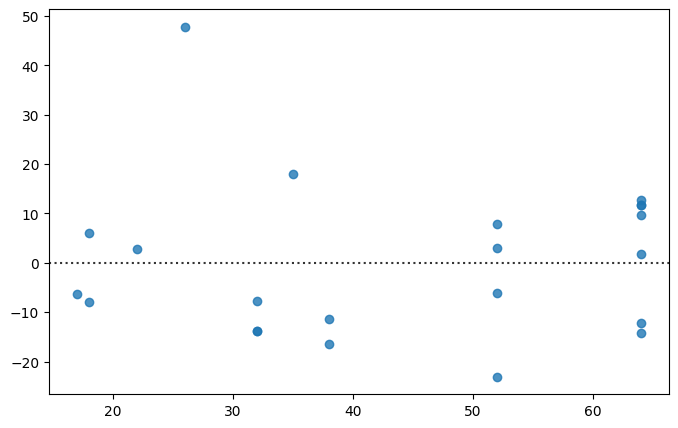

In [29]:
plt.figure(figsize=(8,5))
sns.residplot(data=df, x="MatchesPlayed", y="GoalsScored", lowess=True)
plt.title("Residplot: reziduuri pentru relația GoalsScored ~ MatchesPlayed")
plt.show()

# Boxenplot

- Ce face: arată o estimare (de obicei media) pe categorie + bare de eroare (aici deviație standard).
- Când e util: când vrei să compari tendința centrală între categorii, cu incertitudine/variabilitate.

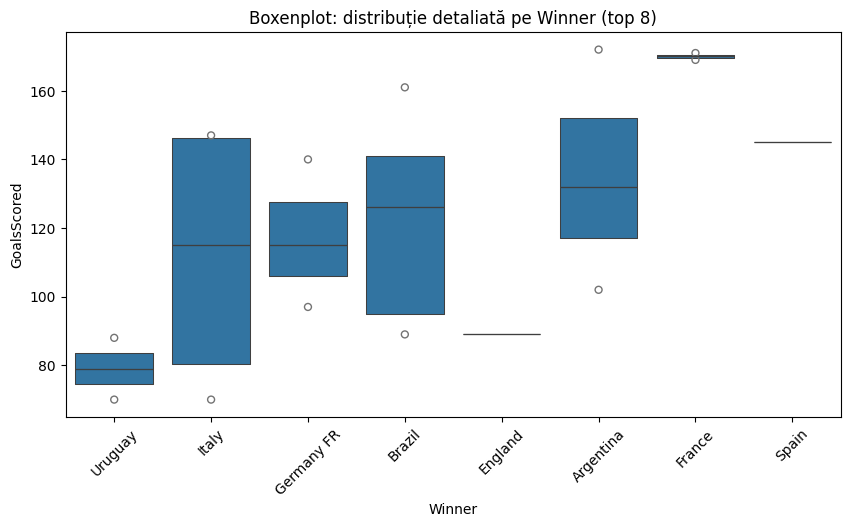

In [ ]:
plt.figure(figsize=(10,5))
sns.boxenplot(data=df_top, x="Winner", y="GoalsScored")
plt.xticks(rotation=45)
plt.title("Boxenplot: distribuție detaliată pe Winner (top 8)")
plt.show()

# Pointplot

- Ce face: arată o estimare (de obicei media) pe categorie + bare de eroare (aici deviație standard).
- Când e util: când vrei să compari tendința centrală între categorii, cu incertitudine/variabilitate.

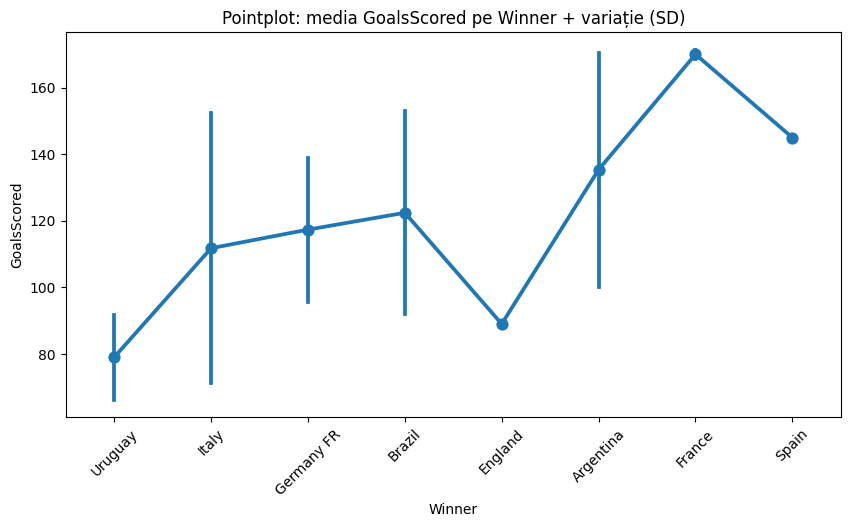

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(data=df_top, x="Winner", y="GoalsScored", errorbar="sd")
plt.xticks(rotation=45)
plt.title("Pointplot: media GoalsScored pe Winner + variație (SD)")
plt.show()

# Catplot

- Ce face: creează un „grid” (figure-level) pentru plot categoric, ușor de combinat cu faceting.
- Când e util: când vrei rapid să schimbi kind sau să adaugi col= / row= pentru comparații pe subgrupuri.

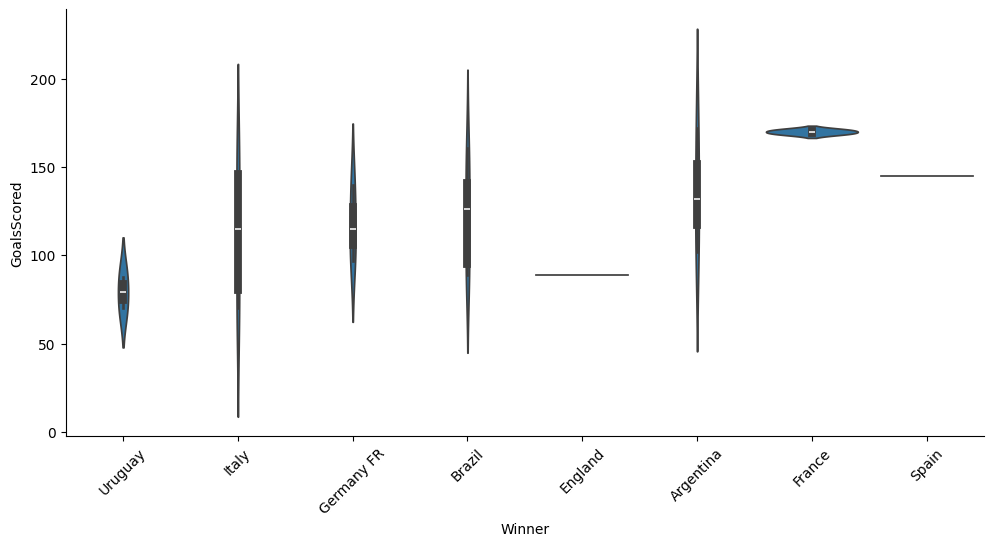

In [ ]:
sns.catplot(data=df_top, x="Winner", y="GoalsScored", kind="violin", height=5, aspect=2)
plt.xticks(rotation=45)
plt.show()

# Ridgeline Plot (joyplot)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_a

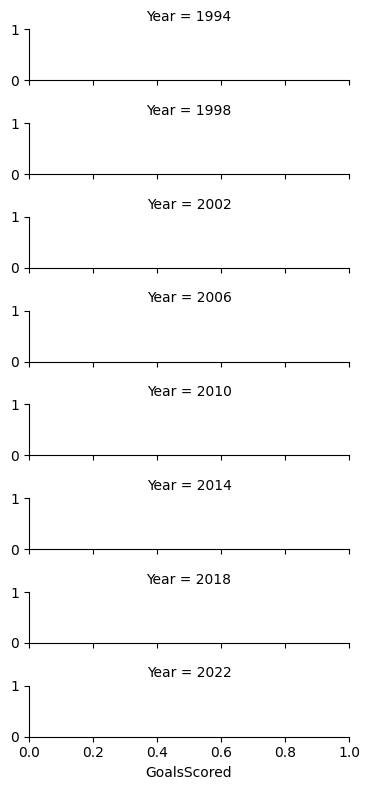

In [ ]:
# ridgeline pe ani (aleg câțiva ani ca să nu fie prea multe rânduri)
years = sorted(df["Year"].unique())[-8:]   # ultimii 8 ani din dataset
df_y = df[df["Year"].isin(years)].copy()

g = sns.FacetGrid(df_y, row="Year", height=1.0, aspect=4)
g.map_dataframe(sns.kdeplot, x="GoalsScored", fill=True, alpha=0.8)
g.set_titles(row_template="Year = {row_name}")
g.set(xlabel="GoalsScored", ylabel="")
plt.show();